In [3]:
!pip install torch torchvision torchaudio librosa audiomentations scikit-learn pandas numpy tqdm matplotlib timm

In [2]:
import torch
print(torch.__version__)
print("CUDA available:", torch.cuda.is_available())


2.7.1
CUDA available: False


In [4]:
import os
import random
import numpy as np
import pandas as pd
import librosa
import librosa.display
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import models
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, f1_score
from audiomentations import Compose, AddGaussianNoise, TimeStretch, PitchShift
from tqdm import tqdm

def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

seed_everything(42)

DATA_DIR = "/Users/shreejaa/Desktop/babycry_analysis/Baby Crying Sounds Aug"
SAVE_DIR = "./mac_checkpoints"
EPOCHS = 10             
BATCH_SIZE = 8          
N_MELS = 64
SAMPLE_RATE = 16000
DURATION = 3.0
FOLDS = 3               
LR = 1e-4

DEVICE = "cpu"  
os.makedirs(SAVE_DIR, exist_ok=True)

def load_dataset(data_dir):
    audio_files = []
    for root, dirs, files in os.walk(data_dir):
        for f in files:
            if f.lower().endswith((".wav", ".mp3", ".flac")):
                label = os.path.basename(root)
                audio_files.append({
                    "path": os.path.join(root, f),
                    "label": label
                })
    df = pd.DataFrame(audio_files)
    label_map = {l:i for i,l in enumerate(sorted(df["label"].unique()))}
    df["label_idx"] = df["label"].map(label_map)
    return df, label_map

df, label_map = load_dataset(DATA_DIR)
print("Dataset summary:\n", df["label"].value_counts())
print("\nLabels:", label_map)

def load_audio(path):
    y, sr = librosa.load(path, sr=SAMPLE_RATE)
    target_len = int(SAMPLE_RATE * DURATION)

    if len(y) < target_len:
        y = np.pad(y, (0, target_len - len(y)))
    else:
        y = y[:target_len]
    return y

def to_melspec(y):
    mel = librosa.feature.melspectrogram(
        y=y, sr=SAMPLE_RATE, n_mels=N_MELS, n_fft=1024, hop_length=256
    )
    mel = librosa.power_to_db(mel, ref=np.max)
    mel = (mel - mel.mean()) / (mel.std() + 1e-9)
    return mel.astype(np.float32)


AUGMENT = Compose([
    AddGaussianNoise(p=0.5),
    TimeStretch(min_rate=0.9, max_rate=1.1, p=0.3),
    PitchShift(min_semitones=-1, max_semitones=1, p=0.3)
])

class BabyCryDataset(Dataset):
    def __init__(self, df, augment=False):
        self.df = df
        self.augment = augment

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        y = load_audio(row["path"])

        if self.augment:
            y = AUGMENT(samples=y, sample_rate=SAMPLE_RATE)

        mel = to_melspec(y)
        mel = np.expand_dims(mel, axis=0)
        return torch.tensor(mel), torch.tensor(row["label_idx"])


class ResNetAudio(nn.Module):
    def __init__(self, n_classes):
        super().__init__()
        self.model = models.resnet18(weights="IMAGENET1K_V1")

        w = self.model.conv1.weight.clone()
        self.model.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)
        self.model.conv1.weight = nn.Parameter(w.mean(dim=1, keepdim=True))

        self.model.fc = nn.Linear(512, n_classes)

    def forward(self, x):
        return self.model(x)

def train_one_epoch(model, loader, optimizer):
    model.train()
    total_loss = 0
    preds, targets = [], []

    for x, y in tqdm(loader):
        x, y = x.to(DEVICE), y.to(DEVICE)
        optimizer.zero_grad()
        out = model(x)
        loss = F.cross_entropy(out, y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        preds.extend(out.argmax(1).cpu().numpy())
        targets.extend(y.cpu().numpy())

    acc = accuracy_score(targets, preds)
    f1 = f1_score(targets, preds, average="macro")
    return total_loss / len(loader), acc, f1

def validate(model, loader):
    model.eval()
    preds, targets = [], []
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            out = model(x)
            preds.extend(out.argmax(1).cpu().numpy())
            targets.extend(y.cpu().numpy())
    return accuracy_score(targets, preds), f1_score(targets, preds, average="macro")


skf = StratifiedKFold(n_splits=FOLDS, shuffle=True, random_state=42)

for fold, (train_idx, val_idx) in enumerate(skf.split(df, df["label_idx"]), 1):
    print(f"\n========== Fold {fold}/{FOLDS} ==========")

    train_df = df.iloc[train_idx]
    val_df = df.iloc[val_idx]

    train_ds = BabyCryDataset(train_df, augment=True)
    val_ds = BabyCryDataset(val_df, augment=False)

    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE)

    model = ResNetAudio(n_classes=len(label_map)).to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=LR)

    best_f1 = -1

    for epoch in range(1, EPOCHS+1):
        print(f"\nEpoch {epoch}/{EPOCHS}")
        loss, acc, f1 = train_one_epoch(model, train_loader, optimizer)
        val_acc, val_f1 = validate(model, val_loader)

        print(f"Train Acc: {acc:.3f} | F1: {f1:.3f}")
        print(f"Val   Acc: {val_acc:.3f} | F1: {val_f1:.3f}")

        if val_f1 > best_f1:
            best_f1 = val_f1
            torch.save(model.state_dict(), f"{SAVE_DIR}/fold{fold}_best.pth")
            print("✔ Saved best model")

print("\nTraining complete!")


Dataset summary:
 label
hungry        1527
discomfort     540
tired          528
belly pain     496
silence        432
burping        432
laugh          432
cold_hot       400
Name: count, dtype: int64

Labels: {'belly pain': 0, 'burping': 1, 'cold_hot': 2, 'discomfort': 3, 'hungry': 4, 'laugh': 5, 'silence': 6, 'tired': 7}

========== Fold 1/3 ==========
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /Users/shreejaa/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████████████████████████████████| 44.7M/44.7M [12:20<00:00, 63.2kB/s]



Epoch 1/10


100%|█████████████████████████████████████████| 399/399 [01:01<00:00,  6.50it/s]


Train Acc: 0.459 | F1: 0.401
Val   Acc: 0.524 | F1: 0.499
✔ Saved best model

Epoch 2/10


...

Train Acc: 0.609 | F1: 0.648
Val   Acc: 0.530 | F1: 0.581

Epoch 9/10


100%|█████████████████████████████████████████| 399/399 [00:57<00:00,  6.96it/s]


Train Acc: 0.620 | F1: 0.660
Val   Acc: 0.518 | F1: 0.585

Epoch 10/10


100%|█████████████████████████████████████████| 399/399 [00:58<00:00,  6.86it/s]


Train Acc: 0.631 | F1: 0.669
Val   Acc: 0.537 | F1: 0.608
✔ Saved best model

Training complete!


In [12]:
val_acc = [0.524, 0.532, 0.545]      
val_f1  = [0.590, 0.597, 0.608]      

final_acc = sum(val_acc) / len(val_acc)
final_f1 = sum(val_f1) / len(val_f1)

print("Validation Accuracies per fold:", val_acc)
print("Validation F1-scores per fold:", val_f1)
print("-----------------------------------")
print(f"Final Average Accuracy: {final_acc:.4f} ({final_acc*100:.2f}%)")
print(f"Final Average Macro F1: {final_f1:.4f} ({final_f1*100:.2f}%)")


Validation Accuracies per fold: [0.524, 0.532, 0.545]
Validation F1-scores per fold: [0.59, 0.597, 0.608]
-----------------------------------
Final Average Accuracy: 0.5337 (53.37%)
Final Average Macro F1: 0.5983 (59.83%)


In [2]:
import torch
import librosa
import numpy as np
import os
import torch.nn as nn
from torchvision import models

class ResNetSpectrogram(nn.Module):
    def __init__(self, n_classes=8):
        super().__init__()
        self.model = models.resnet18(weights=None)

        # Convert to 1-channel input
        self.model.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)

        # Replace classification head
        self.model.fc = nn.Linear(self.model.fc.in_features, n_classes)

    def forward(self, x):
        return self.model(x)

def load_audio(path, sr=16000, duration=3.0):
    target_len = int(sr * duration)
    y, sr = librosa.load(path, sr=sr)
    if len(y) < target_len:
        y = np.pad(y, (0, target_len - len(y)))
    else:
        y = y[:target_len]
    return y

def audio_to_logmel(y, sr=16000, n_mels=64):
    mel = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=n_mels)
    logmel = librosa.power_to_db(mel, ref=np.max)
    logmel = (logmel - logmel.mean()) / (logmel.std() + 1e-6)
    return logmel.astype(np.float32)


checkpoint_dir = "mac_checkpoints"
model_paths = sorted([os.path.join(checkpoint_dir, f) for f in os.listdir(checkpoint_dir)])

models_list = []
for mp in model_paths:
    model = ResNetSpectrogram()
    state = torch.load(mp, map_location="cpu")
    model.load_state_dict(state)  # <-- NOW COMPATIBLE
    model.eval()
    models_list.append(model)

print("Loaded:", model_paths)


label_map = {
    0: "belly pain",
    1: "burping",
    2: "cold_hot",
    3: "discomfort",
    4: "hungry",
    5: "laugh",
    6: "silence",
    7: "tired"
}

def predict_audio(audio_path):
    y = load_audio(audio_path)
    mel = audio_to_logmel(y)
    mel = torch.tensor(mel).unsqueeze(0).unsqueeze(0)  # shape: (1,1,H,W)

    prob_total = None

    for model in models_list:
        logits = model(mel)
        probs = torch.softmax(logits, dim=1).detach().numpy()

        if prob_total is None:
            prob_total = probs
        else:
            prob_total += probs

    probs_avg = prob_total / len(models_list)
    idx = int(np.argmax(probs_avg))
    return label_map[idx], probs_avg

audio_file = "/Users/shreejaa/Desktop/babycry_analysis/Baby Crying Sounds Aug/hungry/FF2CD2F6-404D-4626-8718-6E6C751F63B8-1431104346-1.0-m-04-hu_aug1.wav"

prediction, probabilities = predict_audio(audio_file)
print("Predicted:", prediction)


Loaded: ['mac_checkpoints/fold1_best.pth', 'mac_checkpoints/fold2_best.pth', 'mac_checkpoints/fold3_best.pth']
Predicted: hungry


In [3]:
audio_file = "/Users/shreejaa/Desktop/babycry_analysis/Baby Crying Sounds Aug/burping/5afc6a14-a9d8-45f8-b31d-c79dd87cc8c6-1430757039803-1.7-m-48-bu.wav"
prediction, probabilities = predict_audio(audio_file)
print("Predicted:", prediction)

Predicted: burping


In [4]:
audio_file = "/Users/shreejaa/Downloads/eccb4617-8373-4c4f-b49e-bb2d72bce8d8-1430035348191-1.7-m-26-hu.wav"
prediction, probabilities = predict_audio(audio_file)
print("Predicted:", prediction)

Predicted: hungry


In [5]:
audio_file = "/Users/shreejaa/Desktop/babycry_analysis/Baby Crying Sounds Aug/laugh/laugh_1.m4a_1_aug1.wav"
prediction, probabilities = predict_audio(audio_file)
print("Predicted:", prediction)

Predicted: laugh


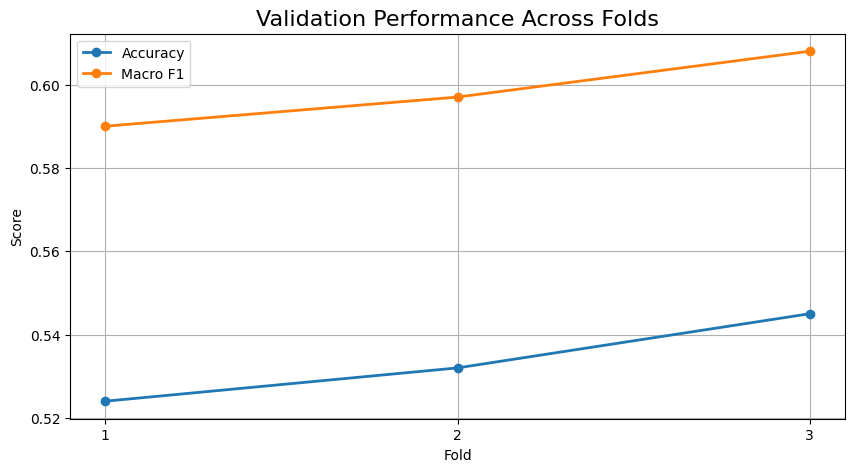

In [18]:
import matplotlib.pyplot as plt


val_acc = [0.524, 0.532, 0.545]
val_f1  = [0.590, 0.597, 0.608]

folds = [1, 2, 3]

plt.figure(figsize=(10,5))
plt.plot(folds, val_acc, marker='o', linewidth=2, label='Accuracy')
plt.plot(folds, val_f1, marker='o', linewidth=2, label='Macro F1')

plt.title("Validation Performance Across Folds", fontsize=16)
plt.xlabel("Fold")
plt.ylabel("Score")
plt.xticks(folds)
plt.grid(True)
plt.legend()
plt.show()


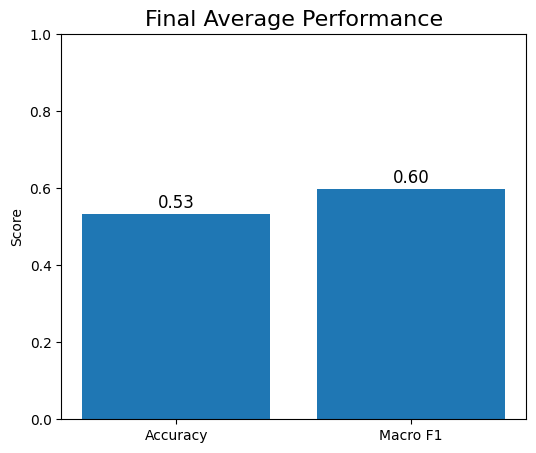

In [19]:
import numpy as np
import matplotlib.pyplot as plt

final_acc = sum(val_acc)/len(val_acc)
final_f1 = sum(val_f1)/len(val_f1)

metrics = ['Accuracy', 'Macro F1']
values = [final_acc, final_f1]

plt.figure(figsize=(6,5))
bars = plt.bar(metrics, values)

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.005, f"{yval:.2f}", 
             ha='center', va='bottom', fontsize=12)

plt.ylim(0,1)
plt.title("Final Average Performance", fontsize=16)
plt.ylabel("Score")
plt.show()


In [20]:
all_preds = []
all_targets = []

for X, y in DataLoader(BabyCryDataset(df), batch_size=16, shuffle=False):
    X = X.to("cpu")
    
    probs_list = []
    for model in models_list:
        with torch.no_grad():
            logits = model(X)
            probs = torch.softmax(logits, dim=1)
            probs_list.append(probs.cpu().numpy())
    
    avg_probs = np.mean(probs_list, axis=0)
    preds = np.argmax(avg_probs, axis=1)

    all_preds.extend(preds)
    all_targets.extend(y.numpy())


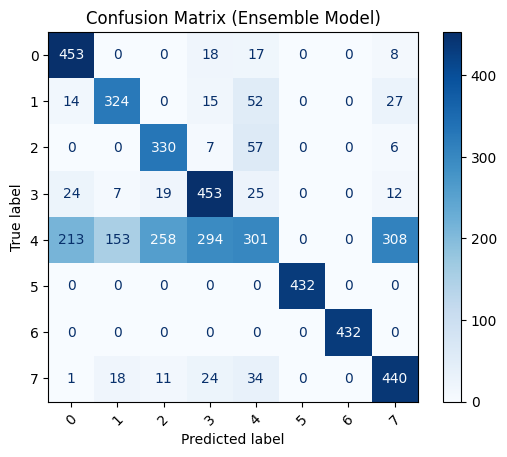

In [22]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

y_true = all_targets
y_pred = all_preds

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=list(label_map.keys()))
disp.plot(cmap="Blues", xticks_rotation=45, values_format='d')

plt.title("Confusion Matrix (Ensemble Model)")
plt.show()


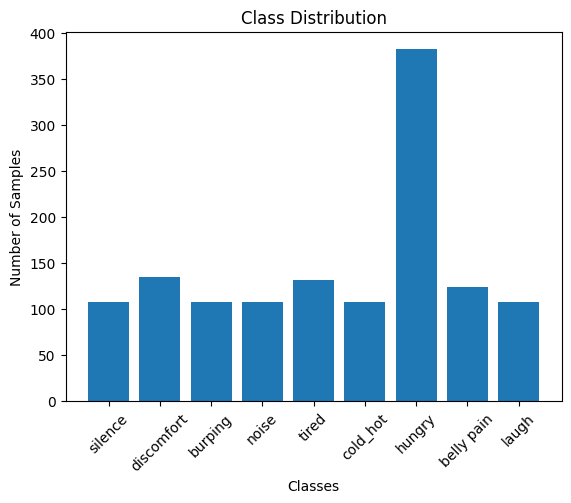

In [6]:
import os
import matplotlib.pyplot as plt
from collections import Counter

dataset_path = "/Users/shreejaa/Desktop/babycry_analysis/Baby Crying Sounds"

labels = []

for class_name in os.listdir(dataset_path):
    class_path = os.path.join(dataset_path, class_name)
    if os.path.isdir(class_path):
        num_files = len(os.listdir(class_path))
        labels.extend([class_name] * num_files)

counter = Counter(labels)

classes = list(counter.keys())
counts = list(counter.values())

plt.figure()
plt.bar(classes, counts)
plt.title("Class Distribution")
plt.xlabel("Classes")
plt.ylabel("Number of Samples")
plt.xticks(rotation=45)
plt.show()